# TASK 2 - v2
## Roland Gulbinovič - 2416108

## Preparation

In [ ]:
!pip install sentence_transformers

In [ ]:
!pip install tf-keras

In [ ]:
!pip install faiss-cpu

In [1]:
from sentence_transformers import SentenceTransformer
import requests
from bs4 import BeautifulSoup
import faiss
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter



## Define functions

In [2]:
def query_ollama(prompt, model="mistral"):
    url = "http://localhost:11434/api/generate"
    response = requests.post(url, json={
        "model": model,
        "prompt": prompt,
        "stream": False  # We want the full output, not streamed chunks
    })
    
    return response.json()['response']

In [3]:
import requests
from bs4 import BeautifulSoup

# Gathers the specificed number of business articles from english version of Delfi.lt
def get_article_links(base_url, num_limit = 5000):
    links = set()
    page = 1

    while len(links) < num_limit:
        url = f"{base_url}?page={page}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')

        for a in soup.select('a[href*="/en/business"]'):
            href = a['href']
            if href.startswith('/'):
                href = f"https://www.delfi.lt{href}"
            links.add(href)

        print(f"Page {page}: collected {len(links)} links...")
        page += 1

    return list(links)[:5000]

# Scrapes the given article
def scrape_article(url):
    try:
        res = requests.get(url)
        soup = BeautifulSoup(res.text, 'html.parser')
        title = soup.find('h1').text.strip()
        paragraphs = soup.find_all('p')
        content = ' '.join(p.text.strip() for p in paragraphs)
        return {'url': url, 'title': title, 'content': content}
    except:
        return None

In [4]:
# Cleans the given text
def clean_text(text):
    return text.replace('\n', ' ').strip()

## Data Preparation

First we need to scrape the website and gather all the text data:

In [5]:
links = get_article_links("https://www.delfi.lt/en/business", num_limit = 5000)

articles = []
for i, url in enumerate(links, start=1):
    article = scrape_article(url)

    if article and article['content']:
        article['content'] = clean_text(article['content'])
        articles.append(article)

    if i % 100 == 0 or i == len(links):
        print(f"Processed {i}/{len(links)} articles...")

Page 1: collected 31 links...
Page 2: collected 61 links...
Page 3: collected 91 links...
Page 4: collected 121 links...
Page 5: collected 151 links...
Page 6: collected 181 links...
Page 7: collected 211 links...
Page 8: collected 241 links...
Page 9: collected 271 links...
Page 10: collected 301 links...
Page 11: collected 331 links...
Page 12: collected 361 links...
Page 13: collected 391 links...
Page 14: collected 421 links...
Page 15: collected 451 links...
Page 16: collected 481 links...
Page 17: collected 511 links...
Page 18: collected 541 links...
Page 19: collected 571 links...
Page 20: collected 601 links...
Page 21: collected 631 links...
Page 22: collected 661 links...
Page 23: collected 691 links...
Page 24: collected 720 links...
Page 25: collected 750 links...
Page 26: collected 780 links...
Page 27: collected 810 links...
Page 28: collected 840 links...
Page 29: collected 870 links...
Page 30: collected 901 links...
Page 31: collected 931 links...
Page 32: collected 9

KeyboardInterrupt: 

In [143]:
len(articles)

4736

In [161]:
# with open("delfi_articles.json", "w", encoding="utf-8") as f:
#     json.dump(articles, f, ensure_ascii=False, indent=2)

In [5]:
with open("delfi_articles.json", "r", encoding="utf-8") as f:
    articles = json.load(f)

In [6]:
articles[1]

{'url': 'https://www.delfi.lt/en/business/over-11-000-reports-on-environmental-violations-received-last-year-in-lithuania-69692118',
 'title': 'Over 11,000 reports on environmental violations received last year in Lithuania',
 'content': "During its first year of activities, the Centre for Information Gathering and Management at the State Environmental Protection Agency (VAAT) of Lithuania, established back in autumn of 2014, received over 11,000 reports on violations of environmental protection requirements, Lithuania's Ministry of Environment said."}

For the transformer I'm using a lightweight pre-trained transformer that is similar to Bert. It turns a sentence into a fixed-size vector (embedding) that captures its semantic meaning.

The input for the transformer is a text corpus, which has all the titles and content of the articles that we scraped earlier.

In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')

corpus = [a["title"] + ". " + a["content"] for a in articles]
doc_embeddings = model.encode(corpus, show_progress_bar=False)

Next we need to put the embeddings into a vector database using FAISS. This lets me retrieve the most relevant documents based on a query embedding.

In [8]:
dim = doc_embeddings[0].shape[0]
index = faiss.IndexFlatL2(dim)
index.add(np.array(doc_embeddings))

## Model Pipeline

Now we define our retrieve and answer generation functions.

Retrieve - we give a query - it embeds it using the same transformer as we did earlier. Then it searches the FAISS vector database for most similar articles.

Generation - Takes the retrieved articles as context and uses a pretrained LLM to generate an answer.

In [9]:
def retrieve(query, top_k=5):
    query_embedding = model.encode([query])
    distances, indices = index.search(np.array(query_embedding), top_k)
    results = [articles[i] for i in indices[0]]
    return results

For the LLM I chose a random open source LLM from https://github.com/eugeneyan/open-llms. The specific one that I chose is trained to understand instructions and generate answers from context.

In [10]:
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
generator = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
def generate_answer(context, query):
    prompt = f"Context:\n{context}\n\nQuestion: {query}"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    outputs = generator.generate(**inputs, max_length=256)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Then we put everything into one function/pipeline. 
Retrieve articles -> gather context -> generate answer.

In [11]:
def rag_pipeline(query, top_k=3):
    retrieved = retrieve(query, top_k=top_k)
    context = "\n\n".join([r["title"] + ": " + r["content"][:500] for r in retrieved])
    return generate_answer(context, query)

In [16]:
answer = rag_pipeline("Which road operator has been working on Vilnius-Utena road?")

In [17]:
answer

'Via Lietuva'

# V2

1) Load a generative model locally - ollama
2) Structured output - keyword or some people names
3) PCA

## 1) & 2)

In [12]:
from pydantic import BaseModel
from typing import List

class RAGResponse(BaseModel):
    answer: str
    keywords: List[str]
    persons: List[str]

In [13]:
def build_prompt(query, articles):
    context = "\n\n".join(
        f"{i+1}. {a['title']}\n{a['content'][:1000]}" for i, a in enumerate(articles)
    )

    prompt = f"""
    Read the following articles and do the following:
    1. Answer the user's question.
    2. Extract **two keywords** that best represent the content.
    3. Extract **two person names** mentioned in the articles.
    
    Return only a JSON object like:
    {{
      "answer": "...",
      "keywords": ["keyword1", "keyword2"],
      "persons": ["name1", "name2"]
    }}
    
    Articles:
    {context}
    
    User's question:
    {query}
    """

    return prompt.strip()

In [22]:
import requests
import re
# This inmputs our prompt into the llama model
def query_ollama_structured(prompt, model="llama3", schema_class=None):
    url = "http://localhost:11434/api/chat"

    response = requests.post(url, json={
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "format": "json",
        "stream": False
    })

    data = response.json()
    content = data.get("message", {}).get("content", "")

    match = re.search(r'{.*}', content, re.DOTALL)
    if not match:
        return None

    json_text = match.group(0)
    return schema_class.model_validate_json(json_text) if schema_class else json_text

In [23]:
def rag_pipeline(query, top_k=5):
    top_articles = retrieve(query, top_k)
    prompt = build_prompt(query, top_articles)
    return query_ollama_structured(prompt, model="llama3.2", schema_class=RAGResponse)

In [24]:
response = rag_pipeline("Vinted")
print("Answer:", response.answer)
print("Keyword:", response.keywords)
print("People:", response.persons)

Answer: Vinted is an online marketplace for second-hand fashion items that has raised 128 million euros in a funding round, making it Lithuania's first 'unicorn' startup.
Keyword: ['fashion', 'marketplace']
People: ['Vilius Šapoka', 'Gintautas Pangonis']


## 3) PCA

In [ ]:
for i, article in enumerate(articles):
    print(f"Extracting keywords for article {i + 1}/{len(articles)}")

    prompt = build_article_keyword_prompt(article)
    response = query_ollama_structured(prompt, model="llama3.2", schema_class=KeywordResponse)

    if response and hasattr(response, "keywords"):
        article["keywords"] = response.keywords
    else:
        article["keywords"] = []

In [20]:
# with open("articles_with_keywords.json", "w", encoding="utf-8") as f:
#     json.dump(articles, f, ensure_ascii=False, indent=2)

In [25]:
with open("articles_with_keywords.json", "r", encoding="utf-8") as f:
    articles = json.load(f)

In [ ]:
from pydantic import BaseModel
from typing import List

class KeywordResponse(BaseModel):
    keywords: List[str]

In [ ]:
def build_article_keyword_prompt(article):
    return f"""
Read the following article and return 1–2 keywords that best describe it.

Return only a JSON object like:
{{ "keywords": ["keyword1", "keyword2"] }}

Article:
Title: {article['title']}
Content: {article['content'][:1000]}
"""

In [41]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
X_pca = pca.fit_transform(doc_embeddings)


# Count how often each keyword appears
label_counts = Counter([a["keywords"][0] if a.get("keywords") else "unknown" for a in articles])
top_keywords = set([kw for kw, _ in label_counts.most_common(10)])  # show only top 10

# Assign "Other" to less common ones
labels = [
    a["keywords"][0] if a.get("keywords") and a["keywords"][0] in top_keywords else "Other"
    for a in articles
]



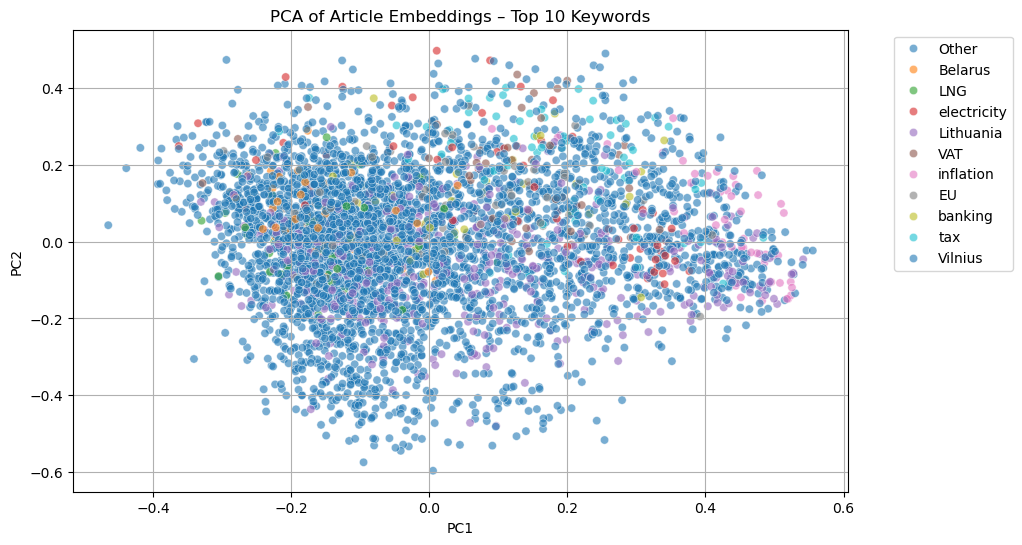

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="tab10", alpha=0.6)
plt.title("PCA of Article Embeddings – Top 10 Keywords")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



This looks pretty messy so we can clean it up by removing all "Other" keywords

In [43]:
label_counts = Counter([a["keywords"][0] if a.get("keywords") else "unknown" for a in articles])
top_keywords = set([kw for kw, _ in label_counts.most_common(10)])

filtered_embeddings = []
filtered_labels = []

for i, a in enumerate(articles):
    if a.get("keywords") and a["keywords"][0] in top_keywords:
        filtered_embeddings.append(doc_embeddings[i])
        filtered_labels.append(a["keywords"][0])

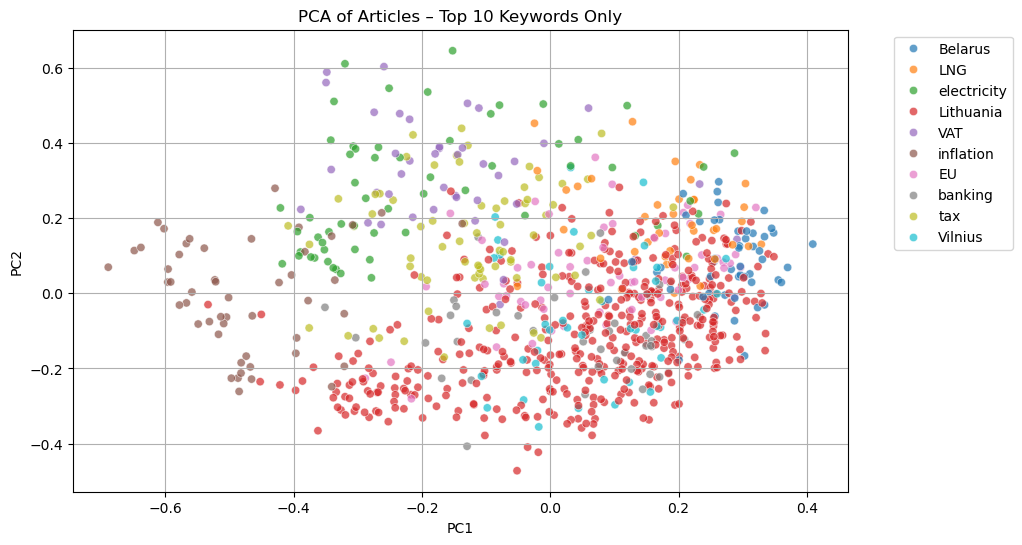

In [44]:
X_pca = PCA(n_components=2).fit_transform(np.array(filtered_embeddings))

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=filtered_labels, palette="tab10", alpha=0.7)
plt.title("PCA of Articles – Top 10 Keywords Only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()